# Solid-Liquid Coexistence and Melting Temperature Calculation
This notebook builds solid-liquid coexisting structures for copper (Cu) and performs molecular dynamics (MD) simulations to determine the melting temperature. The workflow includes:
1. Constructing initial solid-liquid coexisting structures.
2. Running MD simulations at various temperatures.
3. Analyzing the resulting trajectories to estimate the melting temperature from the coexistence data.

In [1]:
# !pip install pyscal3 ase scikit-learn scikit-optimize
#!git clone https://github.com/pyscal/pyscal3.git
#!cd pyscal3;pip install .

## Install and Prepare Dependencies
This section ensures all required Python packages and repositories are available for the simulation and analysis.

### Install and Prepare Dependencies
Install required Python packages and clone necessary repositories for the simulation and analysis. (Commented out if already installed.)

In [2]:
# === Imports and Setup ===
import os
import glob
from pathlib import Path
from copy import deepcopy
from dataclasses import replace
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve

# ASE and related modules for atomistic simulation
from ase.io import read, write, Trajectory
from ase import Atoms, units
from ase.constraints import FixAtoms
from ase.calculators.emt import EMT
from ase.build import stack, bulk
from ase.visualize import view
from ase.optimize import LBFGS

# Parallelization and structure utilities
from joblib import Parallel, delayed

# Import from refactored md_simulation package
from md_simulation import (
    # Core functionality
    MDSimulationParams,
    run_md,
    # Structure tools
    opt_atoms,
    standardize_atoms,
    build_supercell,
    get_expand_cell_func,
    classify_solid_atoms,
)
from md_simulation.structure.analysis import calculate_bulk_modulus
from md_simulation.utils.io import read_yaml

from pfcc_extras.visualize import view_ngl
from pfcc_extras.structure.connectivity import get_connectivity_matrix, get_connected_components, get_neighbors
from pyscal3 import System

MODEL_VERSION = "v7.0.0"
CALC_MODE = 'PBE_PLUS_D3'

def get_calculator(model_version=MODEL_VERSION, calc_mode=CALC_MODE):
    """
    Returns an ASE calculator for the given model version and calculation mode.
    Currently returns EMT as a placeholder.
    """
    calculator = EMT()
    # Uncomment and adjust below for ML/DFT calculator integration
    # if isinstance(calc_mode, str):
    #     calc_mode = getattr(EstimatorCalcMode, calc_mode)
    # estimator = Estimator(model_version=model_version, calc_mode=calc_mode)
    # calculator = ASECalculator(estimator)
    return calculator

In [3]:
# Note: classify_solid_atoms function is now imported from md_simulation package

In [4]:
# Import get_solid_prob function from the refactored package
from md_simulation.structure.analysis import get_solid_prob

In [5]:
def wrap_molecules(atoms, pbc=(1,1,1), replace=False, about='com', eps=1e-7):
    """
    Wrap molecules or clusters within the periodic cell based on their center of mass or Cartesian mean.

    Parameters:
        atoms (ase.Atoms): ASE Atoms object to wrap.
        pbc (tuple): Periodic boundary conditions for each axis (default (1,1,1)).
        replace (bool): If True, modify atoms in place. If False, work on a copy (default False).
        about (str): Use 'com' for center of mass or 'Cartesian' for mean position (default 'com').
        eps (float): Tolerance for numerical errors (default 1e-7).
    Returns:
        ase.Atoms: Atoms object with wrapped molecules/clusters.
    """
    if not replace:
        atoms = atoms.copy()
    _pbc = atoms.get_pbc()
    atoms.set_pbc(False)
    components = get_connected_components(atoms, return_set=True)
    atoms.set_pbc(_pbc)
    cell = atoms.cell.array
    masses = atoms.get_masses()
    if about.lower()=='com':
        # Use center of mass for each molecule/cluster
        mol_positions = np.array([masses[list(indices)] @ atoms.positions[list(indices)] / masses[list(indices)].sum() for indices in components])
    else:  # 'Cartesian'
        mol_positions = np.array([atoms.positions[list(indices)].mean(axis=0) for indices in components])
    scaled_positions = np.linalg.solve(cell.T, np.asarray(mol_positions).T).T
    shift = np.zeros_like(scaled_positions, dtype=float)
    for axis, is_periodic in enumerate(pbc):
        scaled_wrapped = scaled_positions.copy()
        if is_periodic:
            scaled_wrapped[:, axis] %= 1.0
        shift += (scaled_wrapped - scaled_positions)
    shift[np.abs(shift) < 2*eps] = 0
    shift = shift @ cell
    for indices, s in zip(components, shift):
        atoms.positions[list(indices), :] += s
    return atoms

In [6]:
# Set up input and output directories for simulation files
cwd = Path('.')
inputdir = cwd / 'input'
outputdir = cwd / 'output'
for _dir in (inputdir, outputdir):
    _dir.mkdir(exist_ok=True, parents=True)

In [7]:
# Load MD simulation settings and configuration files
md_conf = inputdir / "md.yaml"
geometry_filename = inputdir / "POSCAR"
factor_temp_melt = 1.1

# Read YAML configuration if available
settings = read_yaml(md_conf) if md_conf.exists() else dict()
md_conf = {k:v for k,v in settings.items() if hasattr(MDSimulationParams, k)}
print(settings)
print(md_conf)

{'num_samples': 5, 'num_steps': 10000, 'temperature': 800, 'temperatures': [800, 1000, 1200, 1400, 1600, 1800], 'timestep': 2.0, 'temperatures_coex': [800, 1000, 1200, 1400, 1600]}
{'num_steps': 10000, 'temperature': 800, 'temperatures': [800, 1000, 1200, 1400, 1600, 1800], 'timestep': 2.0}


In [ ]:
# Set up base MD simulation parameters (can be overridden by config)
params_base = MDSimulationParams(
    get_calculator=get_calculator,
    num_steps=10000,
    timestep=2.0,
    temperature=800,
    temperatures=(800, 1000, 1200, 1400, 1600, 1800),
    temp_begin=800,
    temp_end=1800,
    pressure=1.0,  # bar
    taut=500,
    taup=500,
    compressibility=1.0,
    logger=str(outputdir / "mdlogger.log"),  # Store logger in output directory
    ensemble="npt",
    traj_interval=100,
    loginterval=100,
    logger_interval=100,
    overwrite=False,
    attach_functions=None,
)

# Override parameters with those from config if available
params = replace(params_base, **md_conf)
params

In [9]:
# Calculate or load bulk modulus and equation of state (EOS) parameters for the solid
volume_ratio_lim = [0.9, 1.1]
num_data_points = 10
eosfile = outputdir / 'eos.json'
if eosfile.exists():
    with open(eosfile) as f:
        eos_parameters = json.load(f)
    B = eos_parameters['B']
    V0 = eos_parameters['v0']
    E0 = eos_parameters['e0']
else:
    V0, E0, B, eos = calculate_bulk_modulus(solid, volume_ratio_lim, get_calculator, num_data_points, return_eos=True)
    keys = ['B', 'v0', 'v', 'e0', 'e', 'eos_string']
    eos_parameters = {k:getattr(eos, k) for k in keys}
    eos_parameters = {k:list(v) if isinstance(v, np.ndarray) else v for k,v in eos_parameters.items()}
    with open(eosfile, 'w') as f:
        json.dump(eos_parameters, f)
    eos.plot(outputdir/'eos.png', show=True)

print(V0, E0, B)

1249.1363950920127 -0.75820960880997 0.8371744980762933


In [10]:
# Load the equilibrium solid structure from file
solid_equilib = read(outputdir/'solid_equilib.json')

In [11]:
# Prepare annealing parameters for the solid phase (can be customized)
params_solid_anneal = deepcopy(params)
#temperatures = settings.get("temperatures")
#params_solid_anneal.temp_begin = settings.get("temperatures")[0]
#params_solid_anneal.temp_end = settings.get("temperatures")[-1]
# Print the annealing parameters for the solid phase
print(params_solid_anneal)

MDSimulationParams(get_calculator=<function get_calculator at 0x312b82d40>, num_steps=10000, timestep=2.0, temperature=800, temperatures=[800, 1000, 1200, 1400, 1600, 1800], temp_begin=800, temp_end=1800, pfactor=2000000.0, ttime=20.0, pressure=1.0, taut=500, taup=500, compressibility=1.0, fixcm=True, mask=(1, 1, 1), trajfile=None, logfile=None, logger='mdlogger.log', loginterval=100, traj_interval=100, logger_interval=100, ensemble='npt', overwrite=False, check_density=True, attach_functions=None)


## Construct Solid-Liquid Coexistence Structure
Combine the prepared solid and liquid structures to create a solid-liquid coexistence system for MD simulation.

1590.1884436831704
Atoms(symbols='Cu108', pbc=True, cell=[10.962300993130974, 10.98883714298432, 10.931668736710545], momenta=..., calculator=SinglePointCalculator(...))
201
201


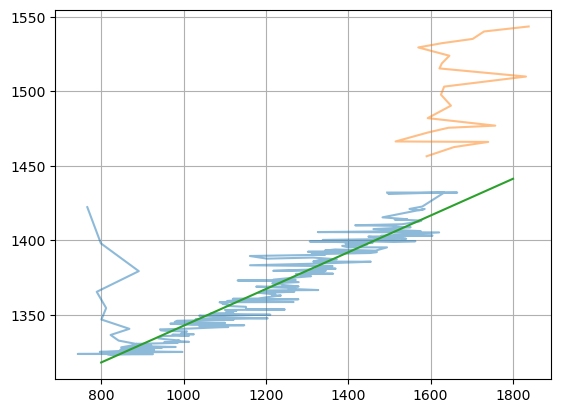

In [12]:
# Load and process solid and melt trajectory data, and prepare for cell expansion
csvfile = outputdir/f'solid_{params_solid_anneal.temp_begin}K_{params_solid_anneal.temp_end}K.csv'
df = pd.read_csv(csvfile)

solid_equilib = read(outputdir/'solid_equilib.json')
temperatures = df['T'].values
volumes = df['V'].values

temperatures_solid = temperatures[df['solid']]
volumes_solid = volumes[df['solid']]

temperatures_melt = temperatures[df['melt']]
volumes_melt = volumes[df['melt']]

melt_temp = temperatures[df['melt']][0]
print(melt_temp)

print(solid_equilib)
plt.plot(temperatures_solid, volumes_solid, alpha=0.5)
plt.plot(temperatures_melt, volumes_melt, alpha=0.5)

window = 2 * int(params.taut / (params.timestep * params.traj_interval))
step = window // 5 if window > 5 else 1
expand_cell = get_expand_cell_func(len(solid_equilib), temperatures_solid, volumes_solid, window=window, step=step)

plt.plot((params.temp_begin, params.temp_end), [expand_cell(solid_equilib, t).get_volume() for t in (params.temp_begin, params.temp_end)])
plt.grid()

print(len(temperatures_solid))
print(len(volumes_solid))

In [13]:
# Prepare solid and melt structures, stack them to create a coexisting structure, and visualize
huge = 1e10
mult_distance = 1.0
is_molecule = False

solidfile = outputdir/'solid_equilib.json'
meltfile = outputdir/'melt.json'
solid_equilib = read(solidfile) if solidfile.exists() else read(f'solid_{params_base.temperature:.0f}K.xyz')
melt = read(meltfile) if meltfile.exists() else read(f'solid_{params.temp_begin:.0f}K_{params.temp_end:.0f}K.traj')

solid = expand_cell(solid_equilib, melt_temp)
solid.wrap()
solid.set_tags(0)
distance = (solid.get_all_distances(mic=True) + huge * np.eye(len(solid_equilib))).min()
distance *= mult_distance
print(distance)

melt.set_cell(solid.cell, scale_atoms=True)
melt = opt_atoms(melt, get_calculator, fmax=0.5, steps=10, maxstep=0.1)
if is_molecule:
    melt = wrap_molecules(melt) 
else:
    melt.wrap()
melt.set_tags(1)

# Stack solid and melt along z-axis to create a coexisting structure
coex = stack(solid, melt,  axis=2, distance=distance)
coex.set_constraint(FixAtoms(mask=coex.get_tags() == 0))

# Visualize the coexisting structure, solid, and melt
view_ngl([coex, solid, melt] , replace_structure=True)

2.272420312168665
       Step     Time          Energy          fmax
LBFGS:    0 19:00:57       46.191222        4.735839
LBFGS:    1 19:00:57       40.287417        2.683857
LBFGS:    2 19:00:57       33.901828        1.872437
LBFGS:    3 19:00:57       30.582238        1.581032
LBFGS:    4 19:00:57       28.929484        1.543381
LBFGS:    5 19:00:57       27.631301        1.487205
LBFGS:    6 19:00:57       26.158679        1.450502
LBFGS:    7 19:00:57       24.962571        1.148759
LBFGS:    8 19:00:57       24.232210        1.089367
LBFGS:    9 19:00:57       23.631139        1.181710
LBFGS:   10 19:00:57       22.901840        1.003900
Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 183
         Function evaluations: 292


## Equilibration of the coexisting structure with fixed solid region

In [ ]:
# Run MD simulation for the coexisting structure with fixed solid region and save the result
params.temperature = melt_temp
params.trajfile = str(outputdir / f"coex_fixsolid_{params.temperature:.0f}K.traj")  # Store in output directory
params.logfile = str(outputdir / f"coex_fixsolid_{params.temperature:.0f}K.log")    # Store in output directory
params.temp_begin = params.temp_end = None
params.mask = (0, 0, 1)
coex_equilib, params = run_md(coex, params)
coex_equilib.write(outputdir/'coex_equilib.json')

In [ ]:
# Visualize the MD trajectory of the coexisting structure
view_ngl(Trajectory(params.trajfile))

## Run Parallel MD Simulations and Collect Solid Probabilities
For each sample and temperature, expand the coexisting structure and run MD simulations in parallel. After each simulation, calculate the solid probability for each structure. The results are stored for further analysis.

In [ ]:
def run_melt_md(it, atoms, temperature, params, outputdir='.'):
    """
    Run MD simulation for a given temperature and iteration, and return the resulting structure as a dictionary.

    Parameters:
        it: Iteration index (int).
        atoms: ASE Atoms object to simulate.
        temperature: Target temperature for the MD run (float).
        params: MDSimulationParams object with simulation settings.
    Returns:
        Dictionary representation of the final ASE Atoms object after MD simulation.
    """
    params.temperature = temperature
    params.temp_begin = params.temp_end = None
    params.trajfile = str(outputdir / f"coex_it{it:02d}_{params.temperature:04.2f}K.traj")  # Store in output directory
    params.logfile = str(outputdir / f"coex_it{it:02d}_{params.temperature:04.2f}K.log")    # Store in output directory
    params.mask = (0, 0, 1)
    atoms.set_constraint()
    atoms, params = run_md(atoms, params)
    return atoms.todict()

In [ ]:
# Print settings and parameters for verification
print(settings)
print(vars(params))


{'num_samples': 5, 'num_steps': 10000, 'temperature': 800, 'temperatures': [800, 1000, 1200, 1400, 1600, 1800], 'timestep': 2.0, 'temperatures_coex': [800, 1000, 1200, 1400, 1600]}
{'get_calculator': <function get_calculator at 0x31bc3f2e0>, 'num_steps': 10000, 'timestep': 2.0, 'temperature': 1624.987290921925, 'temperatures': [800, 1000, 1200, 1400, 1600, 1800], 'temp_begin': None, 'temp_end': None, 'pfactor': 2000000.0, 'ttime': 20.0, 'pressure': 1.0, 'taut': 500, 'taup': 500, 'compressibility': 1.0, 'fixcm': True, 'mask': (0, 0, 1), 'trajfile': 'coex_fixsolid_1625K.traj', 'logfile': 'coex_fixsolid_1625K.log', 'logger': 'mdlogger.log', 'loginterval': 100, 'traj_interval': 100, 'logger_interval': 100, 'ensemble': 'npt', 'overwrite': False, 'check_density': True, 'attach_functions': None}


In [ ]:
# Set up temperature sampling for the coexisting MD simulations
num_jobs = 5
num_iteration = 4
if 'temperatures_coex' in settings:
    temp_sampling_list = settings['temperatures_coex']
else:
    temp_sampling_list = np.linspace(600, 200, num_iteration)
print(temp_sampling_list)

[800, 1000, 1200, 1400, 1600]


In [ ]:
# Run parallel MD simulations for different temperatures and collect solid probabilities
temp_history = []
atoms_history = []
solid_prob_history = []
for sample_id in range(num_jobs):
    # For each sample, expand the coexisting structure to different temperatures
    atoms_list = [expand_cell(coex.copy(), t) for t in temp_sampling_list]

    parallel = Parallel(n_jobs=len(temp_sampling_list), backend='threading')
    atoms_dict_list = parallel(delayed(run_melt_md)(sample_id, coex_equilib, temp, deepcopy(params), outputdir) for coex, temp in zip(atoms_list, temp_sampling_list))

    temp_history.append(temp_sampling_list)
    atoms_list = [Atoms.fromdict(d) for d in atoms_dict_list]
    atoms_history.append(atoms_list)
    solid_prob_list = [
        np.mean(classify_solid_atoms(
            atoms,
            cutoff="adaptive",
            q=6,
            #threshold=0.5,
            #avgthreshold=0.6,
            #cluster=True,
        ))
        for atoms in atoms_list
    ]
    solid_prob_history.append(solid_prob_list)

In [ ]:
# Aggregate results from all iterations and save to CSV for further analysis
data = []
for it, (temp_list, atom_list, prob_list) in enumerate(zip(temp_history, atoms_history, solid_prob_history)):
    for t, a, p in zip(temp_list, atom_list, prob_list):
        data.append((it, t, a.get_volume()/len(a), a.get_masses().sum()/a.get_volume(), p))
df = pd.DataFrame(data, columns=["iteration", "temperature", "volume_per_atom", "density", "solid_prob"])
df.to_csv(outputdir / "coex_melt_md_results.csv", index=False)  # Store CSV in output directory